# IQR 이상치 제거 비교 — 물리 정제 확장 이후 (2026-08-31)

`config.py`의 `CLEANING_RULES`에 물리/설비 임계값을 추가로 확장하고(센서 오류 값들, damper 하한 등),
`data/build_dataset.py`의 정식 파이프라인에서 통계적 IQR 제거를 기본값에서 뺀 뒤(2026-08-31),
그 위에서 **IQR 이상치 제거를 다시 켰을 때/껐을 때** 성능을 재확인한 결과입니다.

이전 버전 비교(`results_iqr_comparison.ipynb`, 2026-08-28)는 물리 정제 확장 **이전** 데이터로 한
것이라 이 노트북과 숫자가 다릅니다 — 그때의 결론("IQR 미적용이 낫다")이 새로 정리한 데이터에서도
그대로 재현되는지 확인하는 게 이 노트북의 목적입니다.

**비교 조건 (context_length는 확정값으로 고정):**
- blaine: `context_length=1024`
- residue: `context_length=1536`
- 둘 다 `--finetune-mode full --prediction-length 4 --learning-rate 1e-6 --num-steps 1000 --batch-size 64`
- **IQR-off**와 **IQR-on** 둘 다 같은(raw/canonical) 테스트셋에서 평가 — naive baseline과 skill-score
  분모가 동일해서 공정 비교입니다.

이 노트북은 GPU를 쓰지 않습니다 — 저장된 `eval/backtest_*.csv`만 읽습니다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    ROOT = ROOT.parents[1] if (ROOT.parents[1] / "config.py").exists() else ROOT
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
CONTEXT_LENGTHS = {"blaine": 1024, "residue": 1536}

# IQR-off는 정식 파이프라인 재정비 직후 학습한 체크포인트, IQR-on은 같은 설정에 IQR만 추가로 켠 것.
# 둘 다 raw(=canonical, IQR 미적용) 테스트셋에서 평가한 결과를 비교합니다.
FILES = {
    "blaine": {
        "IQR 미적용": "backtest_blaine_ctx1024_cleaned.csv",
        "IQR 적용": "backtest_blaine_ctx1024_withiqr_v2_evalraw.csv",
    },
    "residue": {
        "IQR 미적용": "backtest_residue_ctx1536_cleaned.csv",
        "IQR 적용": "backtest_residue_ctx1536_withiqr_v2_evalraw.csv",
    },
}
VARIANTS = ["IQR 미적용", "IQR 적용"]
COLORS = {"IQR 미적용": "#2a78d6", "IQR 적용": "#eb6834"}

print("targets:", TARGETS)
print("context_length:", CONTEXT_LENGTHS)

targets: ['blaine', 'residue']
context_length: {'blaine': 1024, 'residue': 1536}


## 1. 결과 파일 로딩

In [2]:
EVAL_DIR = ROOT / "eval"

results = {}
missing = []
for target in TARGETS:
    results[target] = {}
    for variant, fname in FILES[target].items():
        p = EVAL_DIR / fname
        if p.exists():
            results[target][variant] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            missing.append(str(p))

if missing:
    print("[missing]", len(missing), "files:")
    for m in missing:
        print(" ", m)
else:
    print("전부 로딩 완료:")
    for target in TARGETS:
        for variant in VARIANTS:
            df = results[target][variant]
            print(f"  {target} / {variant}: n={len(df)}")

전부 로딩 완료:
  blaine / IQR 미적용: n=1035
  blaine / IQR 적용: n=1035
  residue / IQR 미적용: n=1036
  residue / IQR 적용: n=1036


## 2. 요약 지표 (pooled MAE/R²/spec 정확도 + macro/정규화 skill-score)

In [3]:
rows = []
for target in TARGETS:
    for variant in VARIANTS:
        df = results[target][variant]
        m = compute_metrics(df, cfg.SPEC_RANGES[target])
        rows.append({
            "target": target, "variant": variant, "context_length": CONTEXT_LENGTHS[target],
            "n": len(df),
            "MAE": round(m["MAE"], 4), "R2": round(m["R2"], 4),
            "spec_accuracy(%)": round(m["spec_accuracy"] * 100, 2),
            "interval_coverage(%)": round(m.get("interval_coverage", float("nan")) * 100, 2),
            "macro_MAE": round(macro_average_mae(df), 4),
            "skill_score": round(normalized_skill_score(df), 4),
        })

summary = pd.DataFrame(rows).set_index(["target", "variant"])
summary

context_length     n      MAE      R2  spec_accuracy(%)  \
target  variant                                                            
blaine  IQR 미적용            1024  1035  69.0849  0.4902             70.14   
        IQR 적용             1024  1035  69.9937  0.4739             70.24   
residue IQR 미적용            1536  1036   0.4089  0.8662             83.30   
        IQR 적용             1536  1036   0.4130  0.8638             82.82   

                 interval_coverage(%)  macro_MAE  skill_score  
target  variant                                                
blaine  IQR 미적용                 44.44    68.9835       0.9965  
        IQR 적용                  45.51    69.8985       1.0101  
residue IQR 미적용                 50.00     0.4088       1.0353  
        IQR 적용                  52.41     0.4130       1.0455

## 3. 타깃별 비교 그래프 (IQR 미적용 vs 적용)

타깃마다 그래프 하나에 네 지표(Skill-score / MAE / R² / Spec 정확도)를 작은 패널로 나눠서, IQR
미적용(파랑)과 적용(주황)을 바로 옆에서 비교할 수 있게 그렸습니다. MAE 패널의 점선은 naive
baseline(직전값 반복) 기준선입니다.

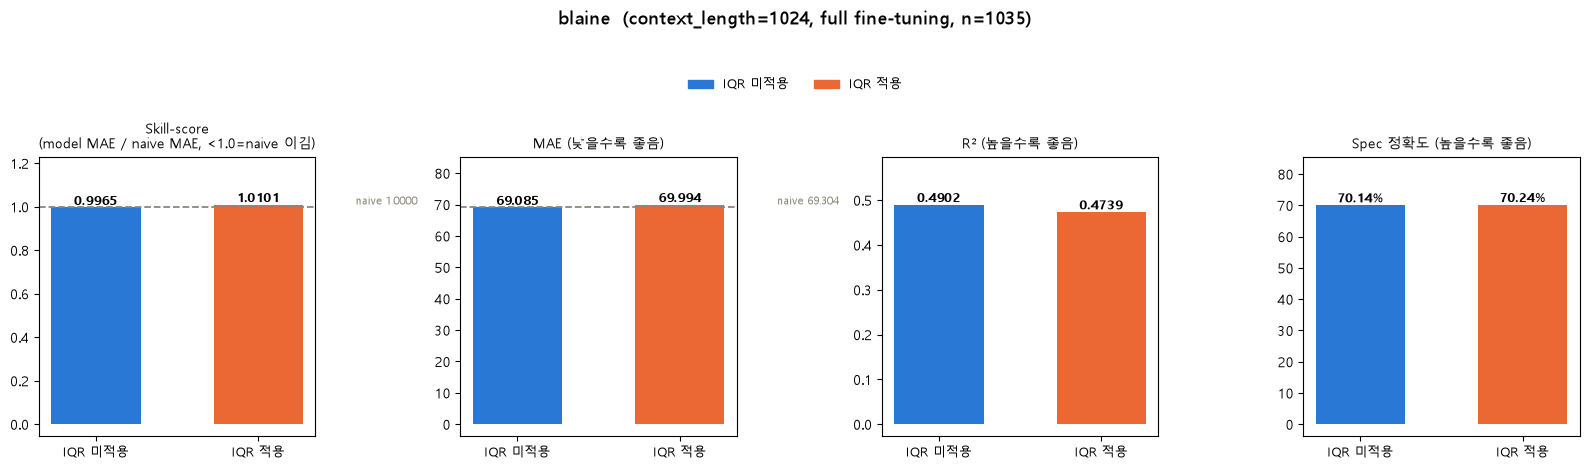

In [4]:
def plot_target_comparison(target: str):
    d = {v: results[target][v] for v in VARIANTS}
    m = {v: compute_metrics(d[v], cfg.SPEC_RANGES[target]) for v in VARIANTS}
    skill = {v: normalized_skill_score(d[v]) for v in VARIANTS}
    naive_mae = float(np.mean([
        np.abs(d[v]["actual"] - d[v]["naive_pred"]).mean() for v in VARIANTS
    ]))  # same test set for both variants, so this is one number either way

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(
        f"{target}  (context_length={CONTEXT_LENGTHS[target]}, full fine-tuning, n={len(d[VARIANTS[0]])})",
        fontsize=13, fontweight="bold", y=1.16,
    )

    def bars(ax, values, title, ylabel, fmt="{:.4f}", naive=None, pct=False):
        xs = np.arange(len(VARIANTS))
        heights = [values[v] for v in VARIANTS]
        bars_ = ax.bar(xs, heights, color=[COLORS[v] for v in VARIANTS], width=0.55)
        for b, v in zip(bars_, heights):
            ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v) + ("%" if pct else ""),
                     ha="center", va="bottom", fontsize=9, fontweight="bold")
        if naive is not None:
            ax.axhline(naive, color="#8b877a", linestyle="--", linewidth=1.3)
            ax.text(len(VARIANTS) - 0.4, naive, f"naive {fmt.format(naive)}", fontsize=8,
                     color="#8b877a", va="bottom")
        ax.set_xticks(xs)
        ax.set_xticklabels(VARIANTS, fontsize=9)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=8)
        lo, hi = ax.get_ylim()
        span = hi - lo
        ax.set_ylim(lo - span * 0.05, hi + span * 0.16)

    bars(axes[0], skill, "Skill-score\n(model MAE / naive MAE, <1.0=naive 이김)", "",
         fmt="{:.4f}", naive=1.0)
    bars(axes[1], {v: m[v]["MAE"] for v in VARIANTS}, "MAE (낮을수록 좋음)", "",
         fmt="{:.3f}", naive=naive_mae)
    bars(axes[2], {v: m[v]["R2"] for v in VARIANTS}, "R² (높을수록 좋음)", "", fmt="{:.4f}")
    bars(axes[3], {v: m[v]["spec_accuracy"] * 100 for v in VARIANTS}, "Spec 정확도 (높을수록 좋음)", "",
         fmt="{:.2f}", pct=True)

    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[v]) for v in VARIANTS]
    fig.legend(handles, VARIANTS, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()


plot_target_comparison("blaine")

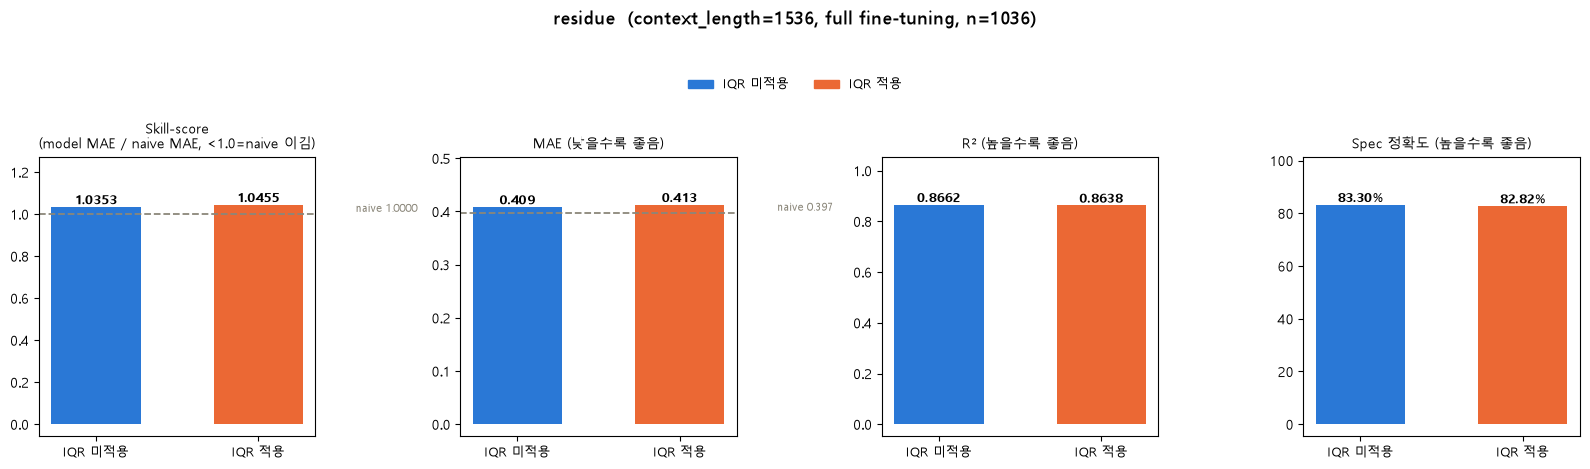

In [5]:
plot_target_comparison("residue")

### 3-1. 같은 비교를 꺾은선(before → after)으로

막대그래프와 같은 4개 지표, 같은 숫자입니다 — IQR 미적용에서 적용으로 넘어갈 때 값이 어느 방향으로
움직이는지를 기울기로 바로 보려면 이쪽이 더 직관적입니다.

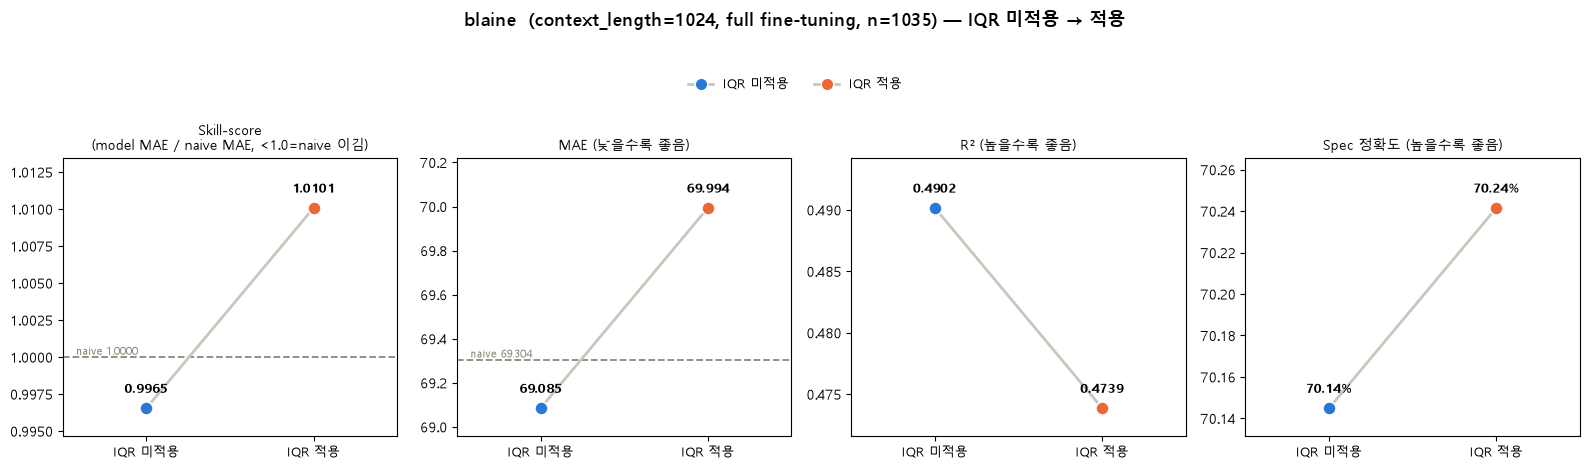

In [6]:
def plot_target_comparison_lines(target: str):
    d = {v: results[target][v] for v in VARIANTS}
    m = {v: compute_metrics(d[v], cfg.SPEC_RANGES[target]) for v in VARIANTS}
    skill = {v: normalized_skill_score(d[v]) for v in VARIANTS}
    naive_mae = float(np.mean([
        np.abs(d[v]["actual"] - d[v]["naive_pred"]).mean() for v in VARIANTS
    ]))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(
        f"{target}  (context_length={CONTEXT_LENGTHS[target]}, full fine-tuning, n={len(d[VARIANTS[0]])}) "
        "— IQR 미적용 → 적용",
        fontsize=13, fontweight="bold", y=1.16,
    )

    def line(ax, values, title, fmt="{:.4f}", naive=None, pct=False):
        xs = np.arange(len(VARIANTS))
        ys = [values[v] for v in VARIANTS]
        ax.plot(xs, ys, color="#c9c6bc", linewidth=2, zorder=1)
        for x, v in zip(xs, VARIANTS):
            ax.scatter(x, values[v], color=COLORS[v], s=90, zorder=3,
                       edgecolor="white", linewidth=1.2)
            ax.annotate(fmt.format(values[v]) + ("%" if pct else ""), (x, values[v]),
                        textcoords="offset points", xytext=(0, 11), ha="center",
                        fontsize=9, fontweight="bold")
        if naive is not None:
            ax.axhline(naive, color="#8b877a", linestyle="--", linewidth=1.3, zorder=0)
            ax.text(-0.42, naive, f"naive {fmt.format(naive)}", fontsize=8,
                     color="#8b877a", va="bottom", ha="left")
        ax.set_xlim(-0.5, len(VARIANTS) - 0.5)
        ax.set_xticks(xs)
        ax.set_xticklabels(VARIANTS, fontsize=9)
        ax.set_title(title, fontsize=10)
        lo, hi = ax.get_ylim()
        span = hi - lo
        ax.set_ylim(lo - span * 0.08, hi + span * 0.18)

    line(axes[0], skill, "Skill-score\n(model MAE / naive MAE, <1.0=naive 이김)",
         fmt="{:.4f}", naive=1.0)
    line(axes[1], {v: m[v]["MAE"] for v in VARIANTS}, "MAE (낮을수록 좋음)",
         fmt="{:.3f}", naive=naive_mae)
    line(axes[2], {v: m[v]["R2"] for v in VARIANTS}, "R² (높을수록 좋음)", fmt="{:.4f}")
    line(axes[3], {v: m[v]["spec_accuracy"] * 100 for v in VARIANTS}, "Spec 정확도 (높을수록 좋음)",
         fmt="{:.2f}", pct=True)

    handles = [plt.Line2D([0], [0], marker="o", color="#c9c6bc", markerfacecolor=COLORS[v],
                           markeredgecolor="white", markersize=9, linewidth=2) for v in VARIANTS]
    fig.legend(handles, VARIANTS, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()


plot_target_comparison_lines("blaine")

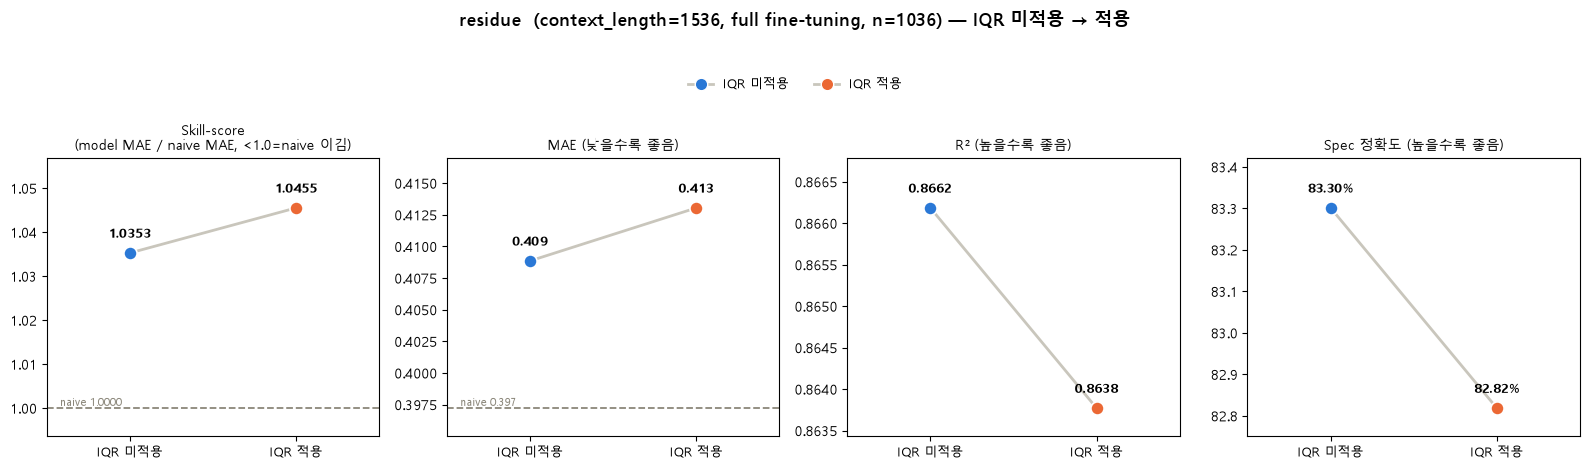

In [7]:
plot_target_comparison_lines("residue")

## 4. 결론

- **두 타깃 모두 IQR 미적용이 우세합니다** — MAE, R², skill-score 전부 IQR 미적용 쪽이 낫습니다.
- **blaine은 IQR을 껐을 때만 naive baseline을 이깁니다**(skill-score 0.9965 < 1.0). IQR을 켜면 다시
  naive에게 집니다(1.0101).
- Spec 정확도·80% 구간 커버리지는 지표별로 승패가 엇갈리지만, 두 지표 다 절대 수준이 낮고
  노이즈에 약하다고 이미 확인된 지표라 이 결론을 뒤집을 근거는 못 됩니다.
- 2026-08-28의 원래 A/B 실험(물리 정제 확장 이전 데이터) 결론이, 데이터를 더 정리한 뒤에도
  **그대로 재현**됐습니다 — 정식 파이프라인을 IQR 미적용으로 확정한 결정은 유효합니다.

**한계**: 여전히 조합당 1회 학습입니다(시드 고정 없음) — 이 결론에 대한 최종 확신은 시드 반복
검증이 남아있습니다.